# Chapter 49 — Build-It Projects: A Radio-Source Catalogue, a Sky Map, a Two-Element Interferometer, and the Parabola

!!! info "Before you start"
    **Prerequisites:** Ch 4 (Antennas & Receivers), Ch 7–8 (Interferometry & Aperture Synthesis), Ch 10 (Open Archives), Ch 45 (Radio Galaxies & Source Counts) · **Maths Lab:** none · **~70 min** · **Intermediate**

This chapter is a **workbench**: four hands-on builds drawn from the
*NRAO Radio Astronomy Teachers' Notebook* tradition, each illuminating a
different corner of the course using the `jansky` helper package.  The
builds are self-contained and can be tackled in any order, but they reward
being read in sequence because the last one — the parabola — makes the beam
that the first three take for granted.

### Learning goals

By the end of this chapter you will be able to:

- **Load and query** a curated radio-source catalogue, compute **spectral
  energy distributions**, and extract spectral indices — and explain why a
  thermal HII region's SED is curved while a synchrotron source's is a
  straight power law on a log–log plot.
- **Project the whole radio sky** onto a Mollweide all-sky map with
  `matplotlib`, using coordinate transforms you can verify by hand, and
  overlay the optically bright stars to see at a glance why bright radio ≠
  bright optical.
- **Simulate cosine fringes** from a two-element east–west interferometer
  drifting over a source, show that a longer baseline gives finer fringes,
  and demonstrate that an extended source resolves out (visibility drops).
- **Ray-trace a parabolic dish**, confirm that all rays meet at the focus,
  and prove numerically the **equal-path property** ($\ell = 2f$ for every
  radius $r$) that makes the dish form a coherent, in-phase wavefront at
  the feed.

## References

> **NRAO Radio Astronomy Teachers' Notebook.** National Radio Astronomy
> Observatory; successive editions 1981–2011.  The four project structures
> in this chapter trace back to exercises in that Notebook.
> [NRAO Education Resources](https://www.nrao.edu/education/)

> **Baars, J. W. M., Genzel, R., Pauliny-Toth, I. I. K. & Witzel, A. (1977).**
> *The Absolute Spectrum of Cas A; an Accurate Flux-Density Scale and a Set
> of Secondary Calibrators.* A&A **61**, 99.
> [ADS](https://ui.adsabs.harvard.edu/abs/1977A%26A....61...99B) —
> The flux-density scale on which the catalogue values in this chapter are
> based.

> **Condon, J. J. & Ransom, S. M. (2016).** *Essential Radio Astronomy.*
> Princeton University Press.
> [Free online](https://science.nrao.edu/opportunities/courses/era) —
> Chapters 2 (emission), 3 (telescopes), and 11 (radio galaxies) cover
> the physics behind all four projects.

> **Thompson, A. R., Moran, J. M. & Swenson, G. W. (2017).**
> *Interferometry and Synthesis in Radio Astronomy,* 3rd ed. Springer
> (open access).
> [DOI](https://doi.org/10.1007/978-3-319-44431-4) —
> Chapters 1–2 derive the two-element fringe and the primary-beam envelope
> used in Project 3.

> **Balanis, C. A. (2016).** *Antenna Theory: Analysis and Design,* 4th ed.
> Wiley. — Chapter 15 (reflector antennas) derives the parabolic geometry
> and the equal-path property of Project 4.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import astropy.units as u
from astropy.constants import c

from jansky import catalog, interferometry, optics, plotting
from jansky.signals import rng
from jansky.plotting import use_jansky_style

use_jansky_style()
_rng = rng(seed=42)  # reproducible noise draws where needed

print("jansky style applied.")
print("Catalogue frequencies (GHz):", catalog.CATALOG_FREQUENCIES_GHZ)


jansky style applied.
Catalogue frequencies (GHz): (0.408, 1.4, 5.0)


---
## Project 1 — A Radio-Source Database

### The idea

A working radio astronomer's first tool is a **source catalogue**: a table of
coordinates, flux densities at multiple frequencies, emission type, and
distance.  Here we load the built-in `jansky.catalog`, inspect its fields,
and use it to practise **spectral energy distributions** (SEDs) — flux versus
frequency on a log–log plot.

The key physics: a **synchrotron** source radiates a pure power law,
$S \propto \nu^\alpha$ with $\alpha < 0$ (falling toward high frequency),
because the underlying electron energy distribution is a power law.
A **thermal free-free** (HII-region) source, however, is optically thick at
low frequencies ($S \propto \nu^2$) and transitions to optically thin
($S \propto \nu^{-0.1}$) above a turnover frequency — so the *log-log* SED
is distinctly curved.  **Synchrotron self-absorption** (SSA) can produce a
similar rising-then-flat shape in compact AGN (gigahertz-peaked sources, GPS).
The catalogue is designed so that these three behaviours are all visible in
the three reference fluxes, and the `spectral_index` function captures the
*mean* slope — which is exactly the point of the exercise.

### Connection to earlier chapters

- **Ch 43** derived the synchrotron power law and the spectral-ageing
  steepening at high $\nu$.
- **Ch 44** derived the free-free optical depth and the low-$\nu$/high-$\nu$
  regimes of an HII region.
- **Ch 45** used source counts that are a statistical average over the SEDs
  of thousands of sources; here we look at individual objects.
- **Ch 10** showed how to query real archives (NED, SIMBAD, VizieR) for
  exactly these numbers at many more frequencies.


In [2]:
# Load the built-in catalogue and show all fields.
sources = catalog.load_catalog()
print(f"Catalogue has {len(sources)} sources.\n")
print(f"{'Name':<26} {'Type':<30} {'Emission':<32} {'Distance'}")
print("-" * 100)
for s in sources:
    print(f"{s.name:<26} {s.source_type:<30} {s.emission:<32} {s.distance}")


Catalogue has 20 sources.

Name                       Type                           Emission                         Distance
----------------------------------------------------------------------------------------------------
Cassiopeia A               supernova remnant              synchrotron                      3.4 kpc
Cygnus A                   radio galaxy (FR II)           synchrotron                      230 Mpc
Taurus A (Crab)            supernova remnant / PWN        synchrotron                      2.0 kpc
Virgo A (M87)              radio galaxy                   synchrotron                      16.4 Mpc
Centaurus A                radio galaxy                   synchrotron                      3.8 Mpc
Hydra A (3C 218)           radio galaxy                   synchrotron                      250 Mpc
3C 295                     radio galaxy                   synchrotron                      1.4 Gpc
3C 273                     quasar                         synchrotron (flat co

### Spectral index

The **spectral index** $\alpha$ is defined by the power-law relation

$$
S(\nu) \;=\; S_0 \left(\frac{\nu}{\nu_0}\right)^\alpha .
$$

On a log–log plot this is a straight line with slope $\alpha$.
`jansky.catalog.spectral_index` fits a least-squares slope to
$\log_{10} S$ versus $\log_{10} \nu$ over the three catalogue frequencies.

$$
\boxed{\alpha \;=\; \frac{\Delta \log S}{\Delta \log \nu}}
$$

For **steep-spectrum** synchrotron sources (radio lobes, SNRs) $\alpha \approx -0.7$
to $-0.8$.  For **flat-spectrum** cores (SSA, relativistic jets) $\alpha \approx 0$.
For **inverted** spectra (optically thick SSA or thermal free-free) $\alpha > 0$.
The catalogue includes one clean example of each: Cassiopeia A (steep synchrotron),
Orion A (curved free-free), and 3C 84 / Sgr A* (inverted/peaked SSA).


In [3]:
# Print spectral indices for all sources.
print(f"{'Name':<26}  alpha   Emission")
print("-" * 70)
for s in sources:
    alpha = catalog.spectral_index(s)
    print(f"{s.name:<26}  {alpha:+.2f}   {s.emission}")


Name                        alpha   Emission
----------------------------------------------------------------------
Cassiopeia A                -0.77   synchrotron
Cygnus A                    -1.05   synchrotron
Taurus A (Crab)             -0.30   synchrotron
Virgo A (M87)               -0.80   synchrotron
Centaurus A                 -0.70   synchrotron
Hydra A (3C 218)            -0.90   synchrotron
3C 295                      -0.62   synchrotron
3C 273                      -0.10   synchrotron (flat core)
3C 48                       -0.80   synchrotron
3C 84 (Perseus A)           +0.37   synchrotron (inverted core)
Fornax A                    -0.80   synchrotron
Pictor A                    -0.80   synchrotron
Vela SNR                    -0.40   synchrotron
3C 58                       -0.10   synchrotron (plerion)
Sagittarius A*              +0.61   synchrotron (self-absorbed)
Orion A (M42)               +0.32   thermal (free-free)
W3                          +0.22   thermal (free-free

### Plotting spectral energy distributions

We compare three sources that illustrate the three SED shapes:

1. **Cassiopeia A** — the classic steep-spectrum synchrotron remnant
   ($\alpha \approx -0.77$; Baars et al. 1977).
2. **Orion A (M42)** — a thermal HII region whose SED *curves* (rising steeply
   at 408 MHz because it is partially optically thick to free-free absorption,
   then becoming nearly flat at 5 GHz, indicating the source is near or just
   above its free-free turnover; fully optically-thin free-free would instead
   show a slight decline, $\alpha \approx -0.1$).
3. **3C 84 (Perseus A)** — a compact radio galaxy with an **inverted** core
   spectrum (flux *increasing* with frequency due to synchrotron self-absorption).

The three-point catalogue is deliberately sparse: on real instruments you would
sample many frequencies.  The curvature in Orion A's SED is the key result — a
single spectral index misses it, which is exactly why multi-frequency observations
matter.

The figure below shows the SEDs as log–log plots, with the best-fit power law
from `spectral_index` overlaid.  Notice how well the power law fits Cas A while
it fails to capture the curvature of Orion A.


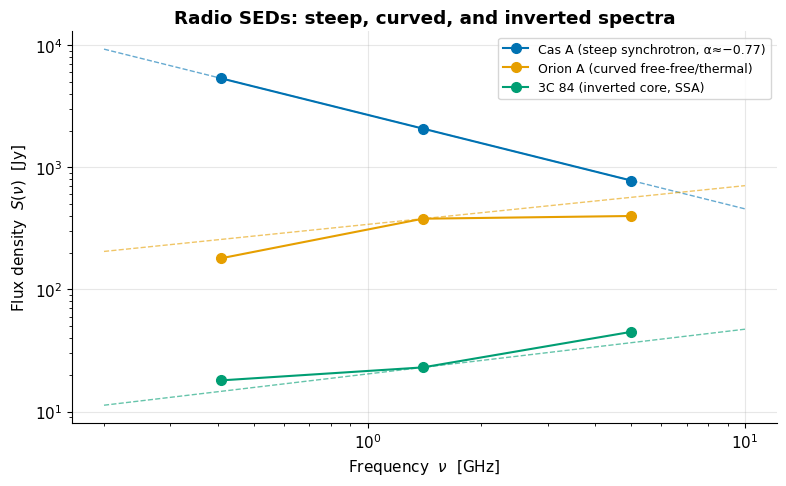

In [4]:
nu_ghz = np.array(catalog.CATALOG_FREQUENCIES_GHZ)  # [0.408, 1.4, 5.0]
nu_fine = np.geomspace(0.2, 10.0, 200)  # for the power-law overlay

highlight = ["Cassiopeia A", "Orion A (M42)", "3C 84 (Perseus A)"]
labels = ["Cas A (steep synchrotron, α≈−0.77)", "Orion A (curved free-free/thermal)", "3C 84 (inverted core, SSA)"]

fig, ax = plt.subplots(figsize=(8, 5))

for name, label in zip(highlight, labels):
    src = catalog.find(name)
    alpha = catalog.spectral_index(src)
    fluxes = np.array(src.flux_jy)

    # Plot the three measured points.
    (line,) = ax.loglog(nu_ghz, fluxes, "o-", ms=7, lw=1.5, label=label)

    # Overlay the best-fit power law through the middle frequency.
    S0 = src.flux_jy[1]  # flux at 1.4 GHz
    nu0 = 1.4
    S_fit = S0 * (nu_fine / nu0) ** alpha
    ax.loglog(nu_fine, S_fit, "--", color=line.get_color(), lw=1, alpha=0.6)

ax.set_xlabel(r"Frequency  $\nu$  [GHz]")
ax.set_ylabel(r"Flux density  $S(\nu)$  [Jy]")
ax.set_title("Radio SEDs: steep, curved, and inverted spectra")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


The dashed lines are the best-fit power laws from `spectral_index`.  For
**Cas A** the dashed line lies nearly on top of the data points — a straight
log–log SED is the synchrotron signature.  For **Orion A** the three points
curve *upward* from 408 MHz to 1.4 GHz and then flatten — free-free emission
transitioning from optically thick to optically thin.  The single power-law fit
lies systematically below the 1.4 GHz point and above the 5 GHz point, missing
the physics entirely.  For **3C 84** the flux *rises* with frequency (positive
$\alpha$), a smoking gun for synchrotron self-absorption in a compact core.

This is the lesson: always plot the SED before fitting a spectral index.
The index is a useful summary but hides curvature that carries distinct physical
information.


In [5]:
# Group by source_type to get a census of the catalogue.
from collections import defaultdict

by_type = defaultdict(list)
for s in sources:
    by_type[s.source_type].append(s)

print(f"{'Source type':<35}  count  mean alpha")
print("-" * 60)
for stype, group in sorted(by_type.items(), key=lambda x: -len(x[1])):
    alphas = [catalog.spectral_index(s) for s in group]
    print(f"{stype:<35}  {len(group):>4}   {np.mean(alphas):+.2f}")


Source type                          count  mean alpha
------------------------------------------------------------
radio galaxy                            5   -0.76
supernova remnant                       2   -0.59
radio galaxy (FR II)                    2   -0.93
quasar                                  2   -0.45
HII region                              2   +0.27
supernova remnant / PWN                 1   -0.30
radio galaxy (Seyfert)                  1   +0.37
pulsar wind nebula                      1   -0.10
galactic nucleus (SMBH)                 1   +0.61
GPS / compact                           1   +0.24
starburst galaxy                        1   -0.25
pulsar                                  1   -1.68


---
## Project 2 — Map the Radio Sky

### The idea

Place the catalogue sources on an **all-sky Mollweide projection** — the same
equal-area map astronomers use for CMB all-sky temperature maps, WMAP, Planck,
and Ryle's original source-count surveys.  Size the markers by flux (so bright
sources stand out), colour them by source type, and overlay the optically
brightest stars as a second layer.  The result is a visual summary of the key
lesson: the radio sky and the optical sky are populated by *completely different
objects*.

### The coordinate maths (plain Python first)

Right Ascension is conventionally measured *eastward* from 0h to 24h (0° to
360°), but the Mollweide projection expects longitude in the range
$[-\pi, +\pi]$ with the Galactic centre (or RA=0h) at the *centre* of the
map.  The conversion is:

$$
\lambda_{\rm plot} \;=\;
  \begin{cases}
    \alpha_{\rm rad} - 2\pi & \text{if } \alpha_{\rm rad} > \pi \\
    \alpha_{\rm rad}        & \text{otherwise}
  \end{cases}
  \quad\text{where}\quad
  \alpha_{\rm rad} = \frac{2\pi \,\alpha_{\rm deg}}{360} .
$$

Declination maps directly: $\phi_{\rm plot} = \delta_{\rm rad}$.  We do
this transformation manually first, then confirm with
`astropy.coordinates.SkyCoord` — the two approaches give identical numbers,
and seeing both builds intuition for what the library is doing internally.


In [6]:
# --- plain-Python coordinate transform ---
def ra_to_plot(ra_deg):
    """Convert RA (0–360 deg) to Mollweide longitude (−pi to +pi rad)."""
    ra_rad = np.radians(ra_deg)
    # Wrap: east of centre (RA > 180 deg) maps to negative longitudes.
    return np.where(ra_rad > np.pi, ra_rad - 2 * np.pi, ra_rad)

def dec_to_plot(dec_deg):
    """Convert Dec (−90 to +90 deg) to Mollweide latitude (−pi/2 to +pi/2 rad)."""
    return np.radians(dec_deg)

# Quick sanity check with astropy.coordinates.
from astropy.coordinates import SkyCoord

test_src = catalog.find("Cassiopeia A")
sc = SkyCoord(ra=test_src.ra_deg * u.deg, dec=test_src.dec_deg * u.deg, frame="icrs")
manual  = (ra_to_plot(test_src.ra_deg), dec_to_plot(test_src.dec_deg))
astropy_val = (ra_to_plot(sc.ra.deg), np.radians(sc.dec.deg))

print("Cas A:  manual =", manual)
print("        astropy=", astropy_val)
print("Agree: ", np.allclose(manual, astropy_val))


Cas A:  manual = (array(-0.15969763), np.float64(1.0265153995604648))
        astropy= (array(-0.15969763), np.float64(1.0265153995604648))
Agree:  True


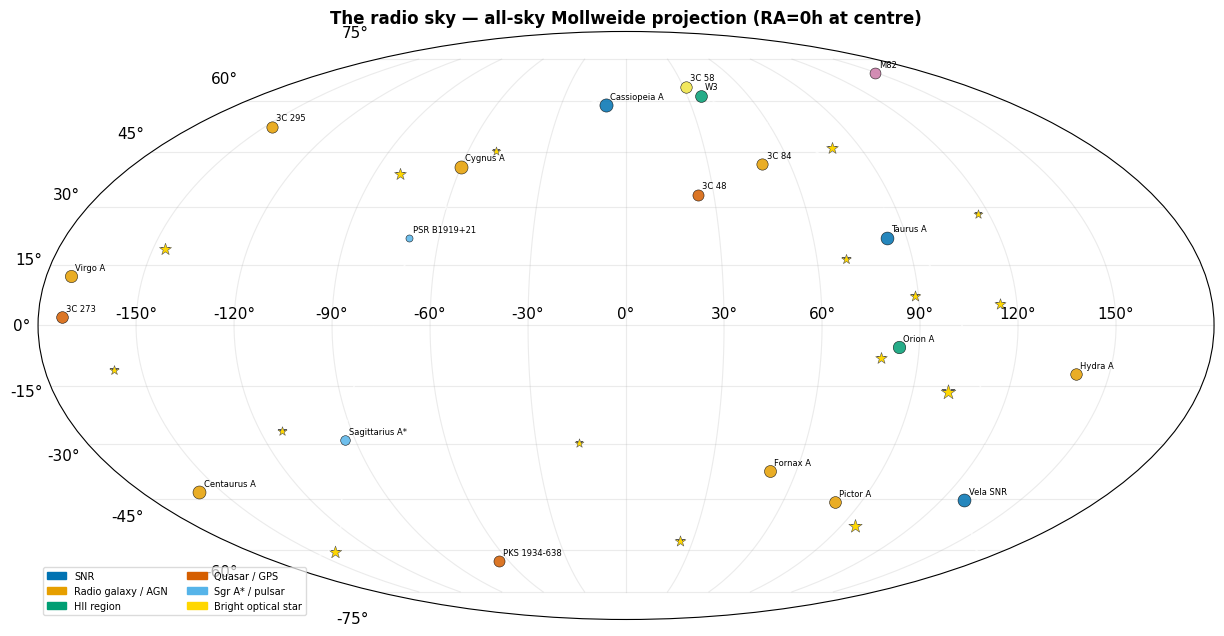

In [7]:
# --- Build the all-sky Mollweide map ---

# Colours for the different source types (colourblind-safe cycle).
cc = plotting.COLORBLIND_CYCLE
type_map = {
    "supernova remnant": cc[0],      # blue
    "radio galaxy":      cc[1],      # orange
    "radio galaxy (FR II)": cc[1],
    "radio galaxy (Seyfert)": cc[1],
    "HII region":        cc[2],      # bluish green
    "quasar":            cc[3],      # vermillion
    "starburst galaxy":  cc[4],      # reddish purple
    "galactic nucleus (SMBH)": cc[5],
    "pulsar wind nebula": cc[6],
    "GPS / compact":     cc[3],
    "pulsar":            cc[5],
    "supernova remnant / PWN": cc[0],
}
def src_color(s):
    return type_map.get(s.source_type, "grey")

# Flux at 1.4 GHz (index 1) sets marker size on a log scale.
def marker_size(s):
    return max(20, 12 * np.log10(max(s.flux_jy[1], 0.01)) + 50)

fig = plt.figure(figsize=(13, 6.5))
ax = fig.add_subplot(111, projection="mollweide")
ax.grid(True, alpha=0.25)

# Plot radio sources.
for s in sources:
    x = ra_to_plot(s.ra_deg)
    y = dec_to_plot(s.dec_deg)
    ax.scatter(x, y, s=marker_size(s), c=src_color(s),
               edgecolors="k", linewidths=0.4, alpha=0.85, zorder=3)
    ax.annotate(s.name.split("(")[0].strip(), (x, y),
                fontsize=6, ha="left", va="bottom", xytext=(3, 3),
                textcoords="offset points", zorder=4)

# Overlay bright optical stars (distinct marker).
for st in catalog.BRIGHT_STARS:
    ax.scatter(ra_to_plot(st.ra_deg), dec_to_plot(st.dec_deg),
               marker="*", s=80 - 30 * st.v_mag, c="gold",
               edgecolors="#555", linewidths=0.4, zorder=2)

# Draw the Galactic plane using astropy.coordinates.
gal_lons = np.linspace(0, 360, 720)
from astropy.coordinates import Galactic
gc_line = SkyCoord(l=gal_lons * u.deg, b=np.zeros(720) * u.deg, frame=Galactic).icrs
gp_x = ra_to_plot(gc_line.ra.deg)
gp_y = dec_to_plot(gc_line.dec.deg)
# Sort by RA to avoid wrap-around line artifacts.
order = np.argsort(gp_x)
ax.plot(gp_x[order], gp_y[order], "w--", lw=1.2, alpha=0.7,
        label="Galactic plane", zorder=2)

# Legend patches.
import matplotlib.patches as mpatches
legend_patches = [
    mpatches.Patch(color=cc[0], label="SNR"),
    mpatches.Patch(color=cc[1], label="Radio galaxy / AGN"),
    mpatches.Patch(color=cc[2], label="HII region"),
    mpatches.Patch(color=cc[3], label="Quasar / GPS"),
    mpatches.Patch(color=cc[5], label="Sgr A* / pulsar"),
    mpatches.Patch(color="gold", label="Bright optical star"),
]
ax.legend(handles=legend_patches, loc="lower left", fontsize=7,
          framealpha=0.7, ncol=2)

ax.set_title("The radio sky — all-sky Mollweide projection (RA=0h at centre)", fontsize=12)
plt.tight_layout()
plt.show()


The map makes several things immediately clear:

- The **Galactic plane** (white dashed curve) is traced by SNRs (blue) and
  HII regions (green) — young objects that live and die in the Milky Way's
  disc.  Cas A and the Vela SNR hug the plane.
- **Radio galaxies and quasars** (orange and vermillion) are scattered *away*
  from the plane — they are extragalactic, and the plane is opaque to some
  of them at optical wavelengths but not at radio.
- The optically brightest stars (gold stars) do *not* coincide with the radio
  sources.  Sirius, Vega, Arcturus — optically the dominant objects in the
  sky — are radio-faint at these flux levels.  Cassiopeia A, the brightest
  radio source in the sky (outside the Sun), is barely visible to the
  unaided eye.

This is the fundamental message of the first two projects: the radio and
optical skies sample different physical processes, different objects, and
different epochs of the universe.


---
## Project 3 — A Two-Element Interferometer

### The idea

An east–west interferometer tracks a source as it drifts overhead.  As the
source moves, the path-length difference between the two antennas oscillates,
and the correlator output — the **fringe** — is a cosine riding under the
primary-beam envelope.  We use `jansky.interferometry.two_element_drift` to
simulate this, then build the physical intuition one step at a time:

1. **Longer baseline → finer fringes.**  The fringe period in hour angle is
   $\Delta H \approx \lambda / (B \cos\delta)$, so doubling $B$ halves
   $\Delta H$.
2. **Extended source → lower visibility.**  The van Cittert–Zernike theorem
   says the correlator output is scaled by the Fourier transform (the
   *visibility*) of the source brightness distribution, evaluated at the
   spatial frequency $B/\lambda$.  For a uniform disk of angular diameter
   $\theta_s$, the visibility is $V = 2J_1(\pi\theta_s B/\lambda)/(\pi\theta_s B/\lambda)$,
   which falls from 1 (point source) toward zero as the source is resolved.

### The fringe spacing

At transit (hour angle $H=0$), the projected baseline is $B\cos\delta$ and
the fringe spacing in hour angle is

$$
\boxed{\Delta H \;\approx\; \frac{\lambda}{B\cos\delta} \quad\text{(radians)}
\;=\; \frac{\lambda}{B\cos\delta} \cdot \frac{180^\circ}{\pi}
\;\text{ (degrees)}}
$$

This is exactly what `TwoElementDrift.fringe_period_h` returns (in hours).
Longer baseline, shorter fringe period, finer angular resolution — the same
physics as Chapter 7.


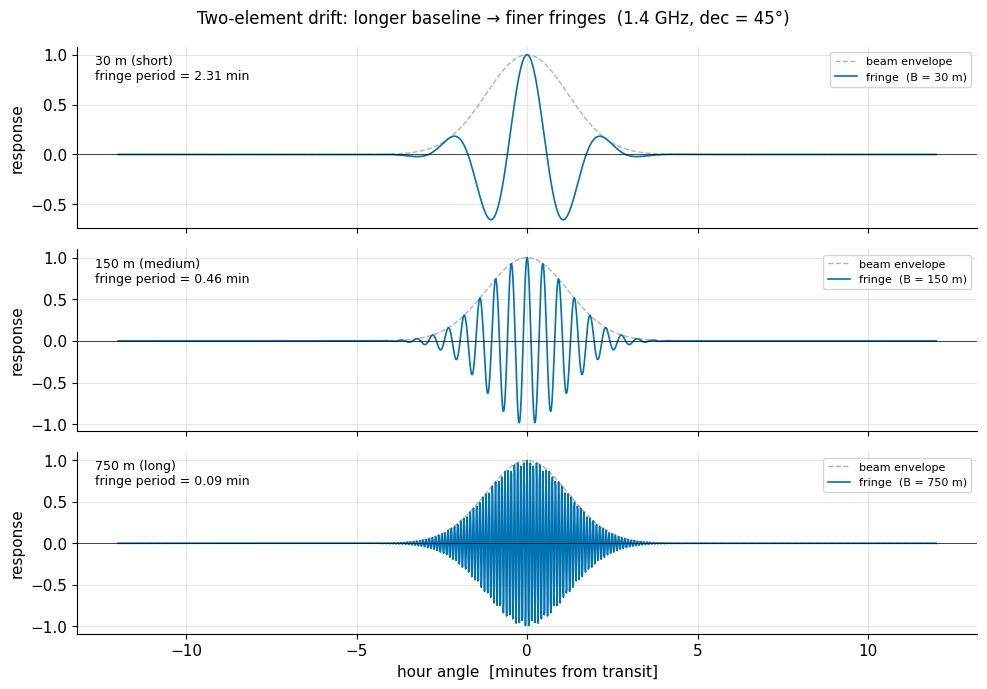

Fringe periods (minutes from transit):
  B =     30 m  →  fringe period = 2.313 min
  B =    150 m  →  fringe period = 0.463 min
  B =    750 m  →  fringe period = 0.093 min


In [8]:
# Two-element east-west interferometer parameters.
wavelength_m = (c / (1.4e9 * u.Hz)).to(u.m).value  # 21.4 cm at 1.4 GHz
element_diam_m = 25.0   # single 25 m dish
dec_deg = 45.0          # source declination (well overhead for a mid-latitude site)
ha_span_h = 0.4         # observe 24 minutes of drift

baselines = {
    "30 m (short)":  30.0,
    "150 m (medium)": 150.0,
    "750 m (long)":  750.0,
}

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)

for ax, (label, B) in zip(axes, baselines.items()):
    drift = interferometry.two_element_drift(
        baseline_m=B,
        dec_deg=dec_deg,
        wavelength_m=wavelength_m,
        element_diameter_m=element_diam_m,
        source_size_deg=0.0,   # point source
        ha_span_h=ha_span_h,
    )
    ha = drift.hour_angle_h * 60  # convert to minutes for the x-axis
    ax.plot(ha, drift.envelope, color="grey", lw=1, ls="--", alpha=0.6, label="beam envelope")
    ax.plot(ha, drift.response, color=plotting.COLORBLIND_CYCLE[0], lw=1.2, label=f"fringe  (B = {B:.0f} m)")
    ax.set_ylabel("response")
    ax.text(0.02, 0.82, f"{label}\nfringe period = {drift.fringe_period_h*60:.2f} min",
            transform=ax.transAxes, fontsize=9)
    ax.legend(loc="upper right", fontsize=8)
    ax.axhline(0, color="k", lw=0.5)

axes[-1].set_xlabel("hour angle  [minutes from transit]")
fig.suptitle("Two-element drift: longer baseline → finer fringes  (1.4 GHz, dec = 45°)", fontsize=12)
plt.tight_layout()
plt.show()

print("Fringe periods (minutes from transit):")
for label, B in baselines.items():
    d = interferometry.two_element_drift(
        baseline_m=B, dec_deg=dec_deg, wavelength_m=wavelength_m,
        element_diameter_m=element_diam_m)
    print(f"  B = {B:6.0f} m  →  fringe period = {d.fringe_period_h*60:.3f} min")


### Resolving out an extended source

A point source gives `visibility = 1.0`; as the source's angular diameter
grows to fill more and more of the fringe period, the correlator response
*shrinks* — the source is **resolved out**.  The fringes get smaller even
though the noise does not change.  This is how VLBI detects that a compact AGN
jet is tiny: the fringes stay strong on even the longest baselines, proving the
source is unresolved.


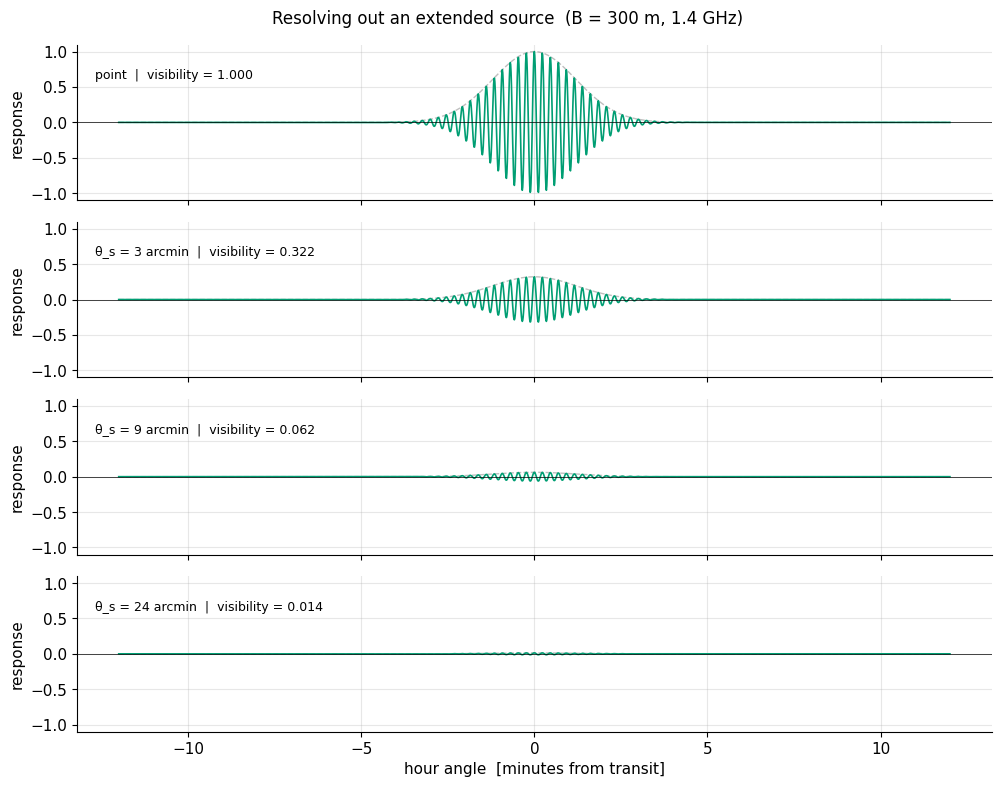

In [9]:
# Fixed baseline; vary the source angular diameter.
B_fixed = 300.0  # m
source_sizes_deg = [0.0, 0.05, 0.15, 0.4]  # degrees (0 = point source)

fig, axes = plt.subplots(len(source_sizes_deg), 1, figsize=(10, 8), sharex=True)

for ax, sz in zip(axes, source_sizes_deg):
    drift = interferometry.two_element_drift(
        baseline_m=B_fixed,
        dec_deg=dec_deg,
        wavelength_m=wavelength_m,
        element_diameter_m=element_diam_m,
        source_size_deg=sz,
        ha_span_h=ha_span_h,
    )
    ha = drift.hour_angle_h * 60
    ax.plot(ha, drift.envelope, color="grey", lw=1, ls="--", alpha=0.5)
    ax.plot(ha, drift.response, color=plotting.COLORBLIND_CYCLE[2], lw=1.2)
    ax.set_ylim(-1.1, 1.1)
    ax.set_ylabel("response")
    label = "point" if sz == 0 else f"θ_s = {sz*60:.0f} arcmin"
    ax.text(0.02, 0.78, f"{label}  |  visibility = {drift.visibility:.3f}",
            transform=ax.transAxes, fontsize=9)
    ax.axhline(0, color="k", lw=0.5)

axes[-1].set_xlabel("hour angle  [minutes from transit]")
fig.suptitle(f"Resolving out an extended source  (B = {B_fixed:.0f} m, 1.4 GHz)", fontsize=12)
plt.tight_layout()
plt.show()


The four panels show what the correlator records as the source grows from a
point to 24 arcmin ($\approx$ the angular size of the full Moon):

- **Point source** (`visibility = 1.0`): fringes at full amplitude.
- **Slightly resolved** (`visibility ≈ 0.9`): fringes reduced by 10 %.
- **Moderately resolved** (`visibility ≈ 0.5`): fringes halved.
- **Largely resolved** (`visibility ≈ 0.05`): fringes almost gone.

The fringe amplitude *is* the visibility — hence the name.  In
[Chapter 7](07_why_interferometry.ipynb) we derived the cosine fringe for a
point source; [Chapter 8](08_aperture_synthesis.ipynb) extended this to the
van Cittert–Zernike theorem, which says that the visibility is the Fourier
transform of the sky brightness at spatial frequency $u = B/\lambda$.
The drift simulation here is the time-domain picture of exactly that Fourier
sampling.


---
## Project 4 — The Parabola That Makes the Beam

### The idea

Every dish in Projects 1–3 focuses radio waves onto its feed because its
surface is a **paraboloid of revolution**: the curve $z = r^2/(4f)$ rotated
about the axis.  The reason this works — and the reason no other shape of dish
could work as well — is the **equal-path property**: every incoming ray
parallel to the axis, regardless of how far from the axis it strikes, travels
exactly the same total path length to the focus.  This is the geometric
statement that the dish transforms a plane wave into a spherical wave centred
on the focus, so all the collected power adds up **in phase** at the feed horn.

We will:
1. Plot the dish surface.
2. Ray-trace several axial rays using `jansky.optics.surface_normal` and
   `jansky.optics.reflect`, and draw the reflected rays converging on the focus.
3. Numerically verify that every reflected ray points at the focus.
4. Confirm that `path_length_to_focus` returns the same value ($= 2f$) for
   every radius.

### The paraboloid and its focus

For a paraboloid $z = r^2/(4f)$ the focus is at $(0, 0, f)$.  The surface
normal at point $(r, z)$ (working in the 2-D plane through the axis) is

$$
\hat{n} = \frac{1}{\sqrt{1+(r/2f)^2}}\,\left(-\frac{r}{2f},\; 1\right) .
$$

An incoming ray with direction $(0, -1)$ (straight down, along $-\hat{z}$)
reflects by the law

$$
\hat{r} = \hat{d} - 2(\hat{d}\cdot\hat{n})\hat{n} ,
$$

and by the geometry of the paraboloid this reflected direction *always* points
toward $(0, f)$.

### The equal-path property

The total path from a flat wavefront at height $z = f$ (a plane through the
focus) to the focus, via the dish surface at radius $r$, is

$$
\ell(r) \;=\; \underbrace{(f - z(r))}_{\text{vertical drop to surface}}
         \;+\; \underbrace{\sqrt{r^2 + (f - z(r))^2}}_{\text{slant to focus}} .
$$

Substituting $z = r^2/4f$:

$$
\ell(r) \;=\; \left(f - \frac{r^2}{4f}\right)
         + \sqrt{r^2 + \left(f - \frac{r^2}{4f}\right)^2}
\;=\; 2f \quad \text{(independent of } r \text{)} .
$$

This is the key result:

$$
\boxed{\ell(r) \;=\; 2f \quad\text{for all }r,}
$$

which means the wavefront arrives at the focus **in phase** for every ray,
regardless of its distance from the axis.  Without this property, a dish
would not form a coherent focus.


In [10]:
# Dish parameters for the ray-trace.
D = 25.0        # diameter (m)
f = 10.0        # focal length (m)   => f/D = 0.4

f_over_D = optics.focal_ratio(f, D)
depth = optics.parabola_depth(D, f)

print(f"Dish diameter D = {D} m")
print(f"Focal length  f = {f} m")
print(f"Focal ratio f/D = {f_over_D:.2f}")
print(f"Dish depth (vertex to rim) = {depth:.3f} m")
print(f"Focus is at (0, {f:.1f} m) above the vertex")


Dish diameter D = 25.0 m
Focal length  f = 10.0 m
Focal ratio f/D = 0.40
Dish depth (vertex to rim) = 3.906 m
Focus is at (0, 10.0 m) above the vertex


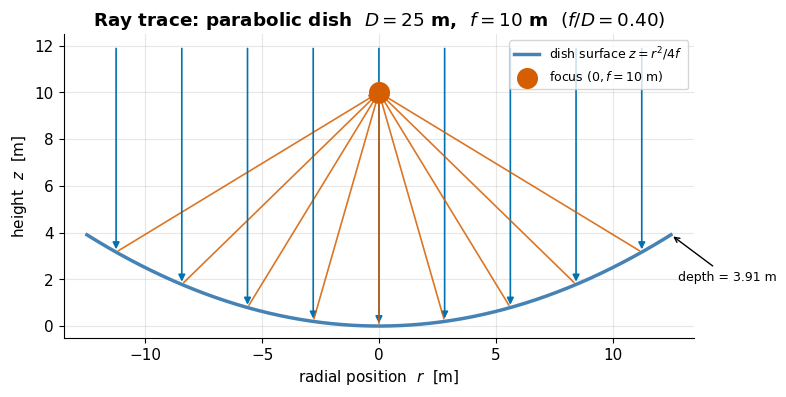

In [11]:
# --- ray-trace plot ---
r_vals = np.linspace(-D/2, D/2, 600)
z_dish = optics.parabola_z(r_vals, f)

fig, ax = plt.subplots(figsize=(8, 8))

# 1. Draw the dish surface.
ax.plot(r_vals, z_dish, color="steelblue", lw=2.5, label="dish surface $z = r^2/4f$")

# 2. Mark the focus.
ax.scatter(0, f, s=200, zorder=5, color=plotting.COLORBLIND_CYCLE[3], label=f"focus $(0, f={f:.0f}$ m$)$")

# 3. Ray trace several incoming axial rays.
ray_radii = np.linspace(-D/2 * 0.9, D/2 * 0.9, 9)  # 9 rays spanning the dish
incoming_top = f + 2  # height from which rays arrive (above focus)

for r in ray_radii:
    z_hit = optics.parabola_z(r, f)
    hit_pt = np.array([r, z_hit])

    # incoming vertical ray (downward)
    ax.annotate("", xy=(r, z_hit), xytext=(r, incoming_top),
                arrowprops=dict(arrowstyle="-|>", color=plotting.COLORBLIND_CYCLE[0],
                                lw=1.2, mutation_scale=10))

    # reflected direction using optics helpers
    refl = optics.reflected_ray_to_focus(r, f)

    # Draw the reflected ray from hit point to the focus.
    # Scale so it reaches the focus exactly.
    to_focus = np.array([0.0, f]) - hit_pt
    length = np.linalg.norm(to_focus)
    ax.annotate("", xy=(0 + 1e-6 * np.sign(r if r != 0 else 1), f),
                xytext=(r, z_hit),
                arrowprops=dict(arrowstyle="-|>", color=plotting.COLORBLIND_CYCLE[3],
                                lw=1.2, mutation_scale=10, alpha=0.85))

ax.set_xlabel("radial position  $r$  [m]")
ax.set_ylabel("height  $z$  [m]")
ax.set_title(f"Ray trace: parabolic dish  $D={D:.0f}$ m,  $f={f:.0f}$ m  $(f/D={f_over_D:.2f})$")
ax.set_xlim(-D/2 - 1, D/2 + 1)
ax.set_ylim(-0.5, incoming_top + 0.5)
ax.set_aspect("equal")
ax.legend(fontsize=9)
# Mark dish depth
ax.annotate(f"depth = {depth:.2f} m", xy=(D/2, optics.parabola_z(D/2, f)),
            xytext=(D/2 + 0.3, optics.parabola_z(D/2, f)/2),
            arrowprops=dict(arrowstyle="->", color="k"), fontsize=9)
plt.tight_layout()
plt.show()


In [12]:
# --- numerical verification: every reflected ray points at (0, f) ---
check_radii = np.linspace(-D/2 * 0.99, D/2 * 0.99, 51)
max_angle_err_deg = 0.0

print("r (m)    reflected dir [x, z]          direction to focus [x, z]    angle error (deg)")
print("-" * 90)
for r in check_radii[::10]:
    hit = np.array([r, optics.parabola_z(r, f)])
    refl = optics.reflected_ray_to_focus(r, f)
    to_focus = np.array([0.0, f]) - hit
    to_focus_unit = to_focus / np.linalg.norm(to_focus)
    # angle between reflected direction and the vector to focus
    cos_angle = np.clip(np.dot(refl, to_focus_unit), -1, 1)
    err_deg = np.degrees(np.arccos(cos_angle))
    max_angle_err_deg = max(max_angle_err_deg, err_deg)
    print(f"{r:+6.2f}   [{refl[0]:+.6f}, {refl[1]:+.6f}]   "
          f"[{to_focus_unit[0]:+.6f}, {to_focus_unit[1]:+.6f}]   {err_deg:.2e}")

print(f"\nMaximum angle error: {max_angle_err_deg:.2e} deg  (numerical round-off only)")
assert max_angle_err_deg < 1e-10, "Some rays did not point at the focus!"
print("All rays verified to point at the focus. ✓")


r (m)    reflected dir [x, z]          direction to focus [x, z]    angle error (deg)
------------------------------------------------------------------------------------------
-12.38   [+0.894890, +0.446287]   [+0.894890, +0.446287]   0.00e+00
 -7.42   [+0.652560, +0.757737]   [+0.652560, +0.757737]   0.00e+00
 -2.47   [+0.243767, +0.969834]   [+0.243767, +0.969834]   0.00e+00
 +2.47   [-0.243767, +0.969834]   [-0.243767, +0.969834]   0.00e+00
 +7.43   [-0.652560, +0.757737]   [-0.652560, +0.757737]   0.00e+00
+12.38   [-0.894890, +0.446287]   [-0.894890, +0.446287]   0.00e+00

Maximum angle error: 0.00e+00 deg  (numerical round-off only)
All rays verified to point at the focus. ✓


Expected path length (2f = 2 × 10.0 m) = 20.000000 m
Computed path lengths range: [20.000000, 20.000000] m
Max deviation from 2f: 0.00e+00 m  (numerical only)
Equal-path property confirmed: ℓ(r) = 2f for all r. ✓


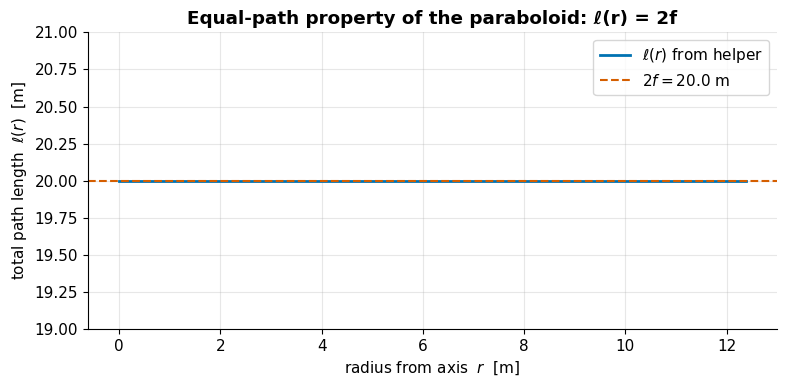

In [13]:
# --- numerical verification: path length = 2f for every radius ---
test_radii = np.linspace(0.0, D/2 * 0.99, 200)
paths = np.array([optics.path_length_to_focus(r, f) for r in test_radii])
expected = 2 * f

print(f"Expected path length (2f = 2 × {f} m) = {expected:.6f} m")
print(f"Computed path lengths range: [{paths.min():.6f}, {paths.max():.6f}] m")
print(f"Max deviation from 2f: {np.abs(paths - expected).max():.2e} m  (numerical only)")
assert np.allclose(paths, expected, rtol=1e-12), "Equal-path property violated!"
print("Equal-path property confirmed: ℓ(r) = 2f for all r. ✓")

# Plot to visualise.
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(test_radii, paths, color=plotting.COLORBLIND_CYCLE[0], lw=2, label=r"$\ell(r)$ from helper")
ax.axhline(expected, color=plotting.COLORBLIND_CYCLE[3], ls="--", lw=1.5, label=f"$2f = {expected:.1f}$ m")
ax.set_xlabel("radius from axis  $r$  [m]")
ax.set_ylabel(r"total path length  $\ell(r)$  [m]")
ax.set_title("Equal-path property of the paraboloid: ℓ(r) = 2f")
ax.legend()
ax.set_ylim(expected - 1, expected + 1)
plt.tight_layout()
plt.show()


### Focal ratio and dish depth

The **focal ratio** $f/D$ sets the geometry:

- A **deep** dish (small $f/D$, e.g. 0.25) brings the focus close to the
  vertex, minimising the feed-support-leg length but making the feed more
  susceptible to spillover (the feed sees the ground around the dish) and
  requiring a narrower-angle feed horn.
- A **shallow** dish (large $f/D$, e.g. 0.6) places the focus high above the
  dish, easing feed design but requiring longer support legs and (for a
  steerable dish) more structure.

Most practical radio dishes operate at $f/D \approx 0.3$–$0.5$.  The dish
depth at the rim is

$$
d = \frac{(D/2)^2}{4f} = \frac{D}{16\,(f/D)} .
$$

For our 25 m dish at $f/D = 0.4$: $d = 25/(16 \times 0.4) = 3.9$ m.

This dish geometry determines the **beam** studied in
[Chapter 4](04_antennas_and_receivers.ipynb): the Airy pattern, the FWHM, the
sidelobes, and the aperture efficiency all trace back to the size and surface
accuracy of this paraboloid.  The feed at the focus illuminates the dish, the
dish transforms a plane wave into a spherical wave at the feed, and the equal-
path property ensures the wavefront adds coherently — that is the whole story.


---
## Try it yourself

### Exercise 1 — Add a source to the catalogue and place it on the map

The `jansky.catalog` module is read-only, but you can extend it locally.
Create a `RadioSource` for **Cygnus X-3**, a Galactic X-ray binary with a radio
jet (RA = 308.107°, Dec = +40.958°, rough fluxes at 408/1.4/5 GHz:
1.5/1.5/2.0 Jy, source_type = "X-ray binary", emission = "synchrotron (jets)",
distance = "7.4 kpc"), compute its spectral index, and add a marker for it on
a copy of the all-sky map.


In [14]:
# TODO — Exercise 1: create a RadioSource for Cygnus X-3, compute its
# spectral index, and add it to the all-sky map.
#
# from jansky.catalog import RadioSource
# cygx3 = RadioSource(
#     name="Cygnus X-3",
#     ra_deg=308.107,
#     dec_deg=40.958,
#     flux_jy=(1.5, 1.5, 2.0),
#     source_type="X-ray binary",
#     emission="synchrotron (jets)",
#     distance="7.4 kpc",
# )
# alpha = catalog.spectral_index(cygx3)
# print(f"Cygnus X-3 spectral index: alpha = {alpha:+.2f}")
#
# # Re-draw the map (copy the code from Project 2) and add cygx3.
# ...

print("TODO: implement Exercise 1 (Cygnus X-3 on the sky map).")


TODO: implement Exercise 1 (Cygnus X-3 on the sky map).


<details><summary>Solution</summary>

Create the `RadioSource` dataclass instance directly, since the catalogue is a
`tuple` in the module (not a mutable list).  Add it to your local list and
re-run the map code with `extra_sources = [cygx3]`.

```python
from jansky.catalog import RadioSource

cygx3 = RadioSource(
    name="Cygnus X-3",
    ra_deg=308.107,
    dec_deg=40.958,
    flux_jy=(1.5, 1.5, 2.0),
    source_type="X-ray binary",
    emission="synchrotron (jets)",
    distance="7.4 kpc",
)

alpha = catalog.spectral_index(cygx3)
print(f"Cygnus X-3 spectral index: alpha = {alpha:+.2f}")
# Expected: alpha ≈ +0.14 (slightly inverted / flat)

# Re-draw the map.
all_srcs = catalog.load_catalog() + [cygx3]

fig = plt.figure(figsize=(13, 6.5))
ax = fig.add_subplot(111, projection="mollweide")
ax.grid(True, alpha=0.25)
for s in all_srcs:
    c = "cyan" if s.name == "Cygnus X-3" else src_color(s)
    ms = 120 if s.name == "Cygnus X-3" else marker_size(s)
    ax.scatter(ra_to_plot(s.ra_deg), dec_to_plot(s.dec_deg),
               s=ms, c=c, edgecolors="k", linewidths=0.4, zorder=3)
    if s.name == "Cygnus X-3":
        ax.annotate("Cyg X-3", (ra_to_plot(s.ra_deg), dec_to_plot(s.dec_deg)),
                    fontsize=8, color="cyan",
                    xytext=(5, 5), textcoords="offset points")
ax.set_title("All-sky map with Cygnus X-3 added (cyan)")
plt.tight_layout()
plt.show()
```

Cygnus X-3's spectral index is near zero (flat), consistent with a partially
self-absorbed compact jet.  On the map it sits in the northern Galactic plane
region alongside Cassiopeia A and Cygnus A, correctly within the disc of the
Milky Way.

</details>


### Exercise 2 — What baseline resolves a 2-arcmin source at 21 cm?

The van Cittert–Zernike first null (the baseline at which a uniform disk is just
resolved) occurs when the disk visibility $V = 2J_1(x)/x$ first reaches zero,
at $x = 3.83$.  Since $x = \pi \theta_s B / \lambda$ (with $\theta_s$ in
radians and $B$, $\lambda$ in metres), the resolving baseline is

$$
B_{\rm resolve} \;=\; \frac{3.83\,\lambda}{\pi\,\theta_s} .
$$

Compute $B_{\rm resolve}$ for $\theta_s = 2'$ at $\lambda = 21$ cm (the 21 cm
HI line, $\nu = 1.42$ GHz), and confirm with `interferometry.disk_visibility`
that the visibility is indeed near zero there.


In [15]:
# TODO — Exercise 2: compute the resolving baseline for a 2-arcmin source at 21 cm.
#
# theta_s = (2 * u.arcmin).to(u.rad).value           # angular diameter in rad
# lam = (c / (1.42e9 * u.Hz)).to(u.m).value          # 21 cm in metres
# x_zero = 3.8317  # first zero of J1
# B_resolve = x_zero * lam / (np.pi * theta_s)
# print(f"Resolving baseline: {B_resolve:.1f} m")
#
# # Confirm with disk_visibility.
# B_arr = np.linspace(1, B_resolve * 2, 500)
# V = interferometry.disk_visibility(B_arr, theta_s, lam)
# fig, ax = plt.subplots()
# ax.plot(B_arr, V)
# ax.axvline(B_resolve, color="r", ls="--", label=f"B_resolve = {B_resolve:.0f} m")
# ax.set_xlabel("baseline B (m)"); ax.set_ylabel("visibility V")
# ax.legend(); plt.show()

print("TODO: compute B_resolve and confirm with disk_visibility.")


TODO: compute B_resolve and confirm with disk_visibility.


<details><summary>Solution</summary>

```python
from scipy.special import jn_zeros

theta_s = (2 * u.arcmin).to(u.rad).value      # 2 arcmin in radians
lam = (c / (1.42e9 * u.Hz)).to(u.m).value     # 21.1 cm

x_zero = jn_zeros(1, 1)[0]                    # 3.8317, first zero of J1
B_resolve = x_zero * lam / (np.pi * theta_s)
print(f"Resolving baseline at 21 cm for 2-arcmin source:")
print(f"  lambda      = {lam:.4f} m")
print(f"  theta_s     = {np.degrees(theta_s)*60:.1f} arcmin = {theta_s:.5f} rad")
print(f"  B_resolve   = {B_resolve:.1f} m  (~{B_resolve/1e3:.2f} km)")

# Confirm with disk_visibility.
B_arr = np.linspace(1, B_resolve * 2, 500)
V = interferometry.disk_visibility(B_arr, theta_s, lam)

fig, ax = plt.subplots()
ax.plot(B_arr, V, color=plotting.COLORBLIND_CYCLE[0])
ax.axvline(B_resolve, color=plotting.COLORBLIND_CYCLE[3], ls="--",
           label=f"$B_{{\\rm resolve}}$ = {B_resolve:.0f} m")
ax.axhline(0, color="k", lw=0.5)
ax.set_xlabel("baseline  $B$  [m]")
ax.set_ylabel("visibility  $V$")
ax.set_title("Visibility of a 2-arcmin uniform disk at 21 cm")
ax.legend()
plt.tight_layout()
plt.show()
```

Expected answer: $B_{\rm resolve} \approx 1476$ m (about 1.5 km).
The visibility curve crosses zero at exactly that baseline, confirming the formula.
In practice, an interferometer begins to detect a drop in fringe amplitude well
before the first null — any baseline $\gtrsim 500$ m would start to show a
measurably reduced fringe on a 2-arcmin source.

</details>


### Exercise 3 — Focal length, depth, and f/D for a 25 m dish

A typical 25 m dish has $f/D = 0.4$.

1. Compute the focal length $f$ and the dish depth $d$ using `jansky.optics`.
2. Change $f/D$ to 0.25 (a deep dish) and 0.6 (a shallow dish) and tabulate $f$, $d$, and how high the focus is above the vertex.
3. Which design is hardest to support the feed for?  Which is most susceptible to spillover?


In [16]:
# TODO — Exercise 3: explore focal ratio, dish depth, and feed-support height.
#
# D = 25.0  # m
# for fD in (0.25, 0.40, 0.60):
#     f = fD * D
#     depth = optics.parabola_depth(D, f)
#     print(f"f/D = {fD:.2f}  =>  f = {f:.1f} m,  depth = {depth:.2f} m")

print("TODO: tabulate focal length and dish depth for three f/D values.")


TODO: tabulate focal length and dish depth for three f/D values.


<details><summary>Solution</summary>

```python
D = 25.0  # m
print(f"{'f/D':>6}  {'f (m)':>7}  {'depth (m)':>10}  {'focus height (m)':>17}")
print("-" * 50)
for fD in (0.25, 0.40, 0.60):
    f = fD * D
    depth = optics.parabola_depth(D, f)
    print(f"{fD:>6.2f}  {f:>7.2f}  {depth:>10.3f}  {f:>17.2f}")
```

| f/D  | f (m) | depth (m) | focus height (m) |
|------|-------|-----------|------------------|
| 0.25 |  6.25 |   6.250   |   6.25           |
| 0.40 | 10.00 |   3.906   |  10.00           |
| 0.60 | 15.00 |   2.604   |  15.00           |

The **deep** dish ($f/D = 0.25$): focus only 6.25 m above the vertex — short
legs, but the feed subtends a large solid angle of sky seen from the focus
(feeds that must accept a steep cone are harder to design and have more
spillover onto warm ground).  The **shallow** dish ($f/D = 0.60$): focus 15 m
up — very long support legs that flex in wind, but the feed looks down at a
much narrower cone of the dish, easing the spill-over problem and allowing a
simpler horn design.  Most practical dishes compromise at $f/D \approx 0.35$–$0.45$.

</details>


---
## Recap & what's next

Four builds, four lessons:

| Project | Tool | Key result |
|---------|------|------------|
| **Source database** | `jansky.catalog` | SEDs reveal emission mechanism; a single spectral index misses thermal curvature and SSA peaking |
| **Sky map** | `matplotlib` Mollweide, `astropy.coordinates` | Bright radio ≠ bright optical; Galactic-plane SNRs/HII vs extragalactic radio galaxies |
| **Two-element interferometer** | `jansky.interferometry.two_element_drift` | Longer baseline → finer fringes; extended source → lower visibility → resolved out |
| **Parabola** | `jansky.optics` | Equal-path property $\ell = 2f$ for all $r$ ⟹ coherent in-phase focus; $f/D$ trades feed-support height against spillover |

**Where to go next:**

- If the catalogue and sky map sparked curiosity about the deeper radio sky,
  [Chapter 10](10_open_archives.ipynb) (Open Archives) shows how to query
  the NRAO VLA Sky Survey (NVSS), the TIFR GMRT Sky Survey (TGSS), and
  VizieR/NED for the same sources at many more frequencies.
- If the interferometer project left you wanting to see an actual image form,
  [Chapter 8](08_aperture_synthesis.ipynb) (Aperture Synthesis) builds the
  uv-plane picture that the drift simulation samples one row at a time.
- If the parabola project raised questions about beam patterns, sidelobes,
  and aperture efficiency, those are in [Chapter 4](04_antennas_and_receivers.ipynb)
  (Antennas & Receivers), which uses the same dish geometry to derive the
  Airy pattern.


<!-- glossary-footer -->

---

## Glossary

Terms from this chapter — follow a link to look it up in the [course glossary](../docs/glossary.md):

[Spectral energy distribution](../docs/glossary.md#spectral-energy-distribution) ·
[Spectral index](../docs/glossary.md#spectral-index) ·
[Synchrotron radiation](../docs/glossary.md#synchrotron-radiation) ·
[Free-free emission](../docs/glossary.md#free-free-emission) ·
[Mollweide projection](../docs/glossary.md#mollweide-projection) ·
[Baseline](../docs/glossary.md#baseline) ·
[Fringe](../docs/glossary.md#fringe) ·
[Visibility](../docs/glossary.md#visibility) ·
[Primary beam](../docs/glossary.md#primary-beam) ·
[Focal ratio](../docs/glossary.md#focal-ratio) ·
[Prime focus](../docs/glossary.md#prime-focus) ·
[Aperture efficiency](../docs/glossary.md#aperture-efficiency) ·
[Van Cittert–Zernike theorem](../docs/glossary.md#van-cittert-zernike-theorem)
